Hilbert Matrix simulation 1



--- Error Analysis ---
Left extreme error  (log10(alpha)=-10.00): 2.279933e+00
Right extreme error (log10(alpha)=5.00): 9.999963e-01

Minimum error: 7.357605e-01
Occurs at log10(alpha) = -5.872483
Equivalent alpha = 1.341272e-06
Maximum alpha tested: 1.000000e+05
Execution time: 0.0727 seconds


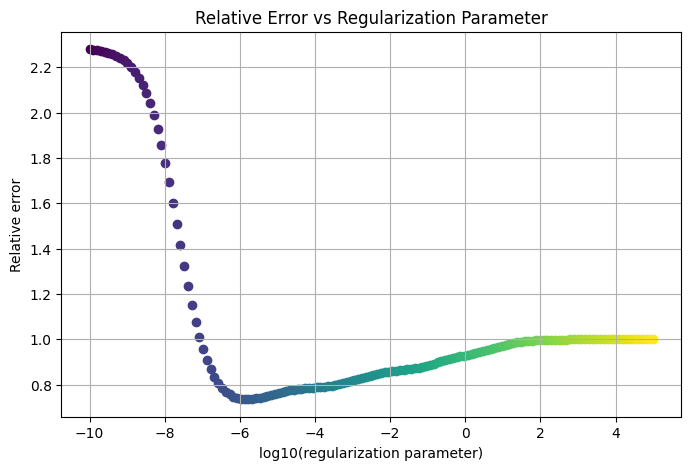

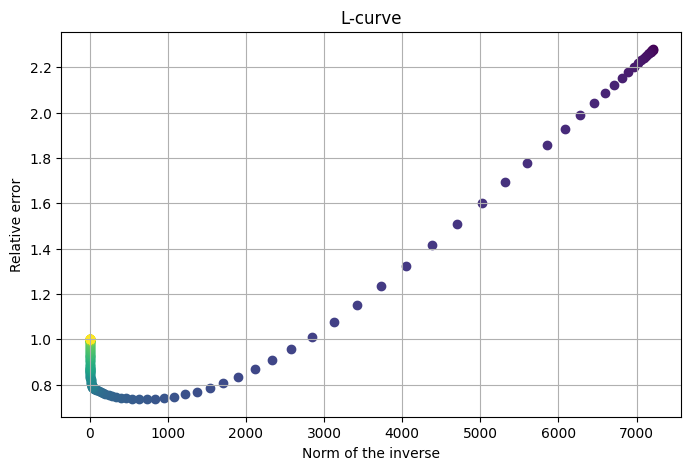

Images saved successfully.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + r * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    # Tamaño de la matriz
    n = 8

    # RANGO MODIFICADO: ahora hasta x = 5
    # (antes era hasta 0)
    regularization_values = np.linspace(-10, 5, 150)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # Análisis de errores

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error  (log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error (log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    print(
        f"Maximum alpha tested: {10**regularization_values[-1]:.6e}"
    )

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title(
        "Relative Error vs Regularization Parameter"
    )

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully.")

Save figures


In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 2



--- Error Analysis ---
Left extreme error (log10(alpha)=-10.00): 4.034311e+00
Right extreme error (log10(alpha)=5.00): 9.999986e-01

Minimum error: 9.261855e-01
Occurs at log10(alpha) = -5.067114
Equivalent alpha = 8.568127e-06
Execution time: 0.1488 seconds


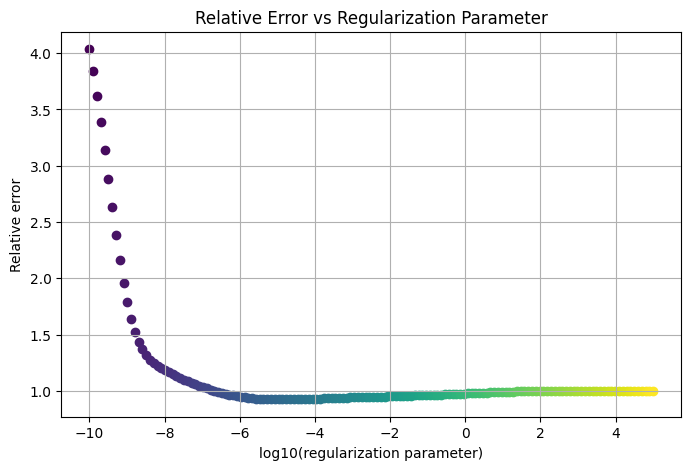

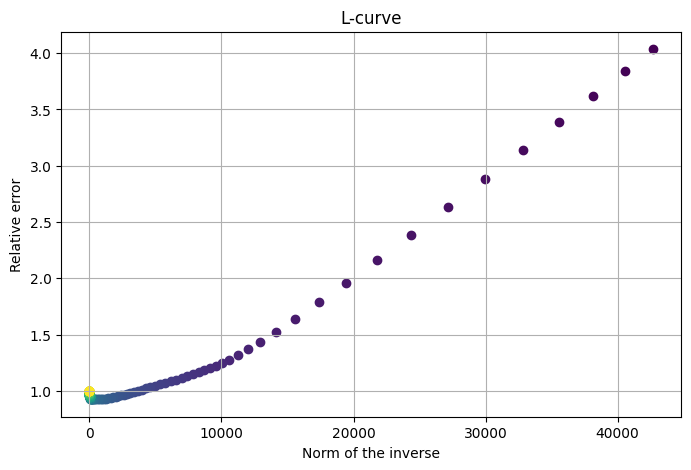

Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

# Para descargar archivos en Colab
from google.colab import files


def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I


def compute_errors(n, regularization_values, num_trials=10):

    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + r * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    n = 30

    # 🔴 RANGO MODIFICADO (ahora hasta x=5)
    regularization_values = np.linspace(-10, 5, 150)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # --------- ANÁLISIS ---------

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error "
        f"(log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error "
        f"(log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title("Relative Error vs Regularization Parameter")

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully in the Colab environment.")



Save figures

In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 3



--- Error Analysis ---
Left extreme error  (log10(alpha)=-10.00): 2.234367e+00
Right extreme error (log10(alpha)=5.00): 9.999999e-01

Minimum error: 9.972277e-01
Occurs at log10(alpha) = -3.456376
Equivalent alpha = 3.496425e-04
Maximum alpha tested: 1.000000e+05
Execution time: 587.3748 seconds


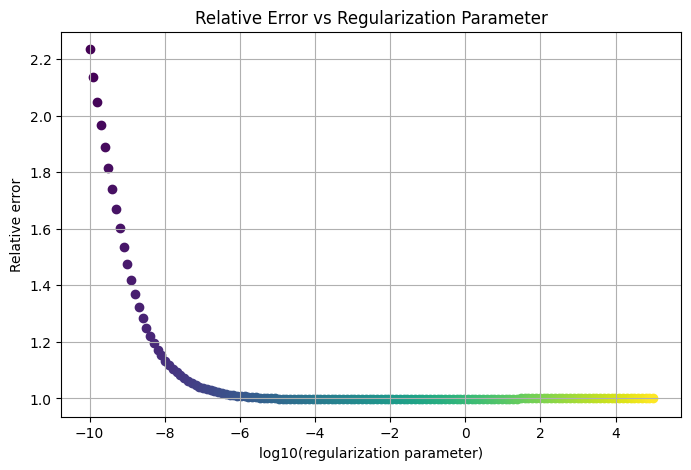

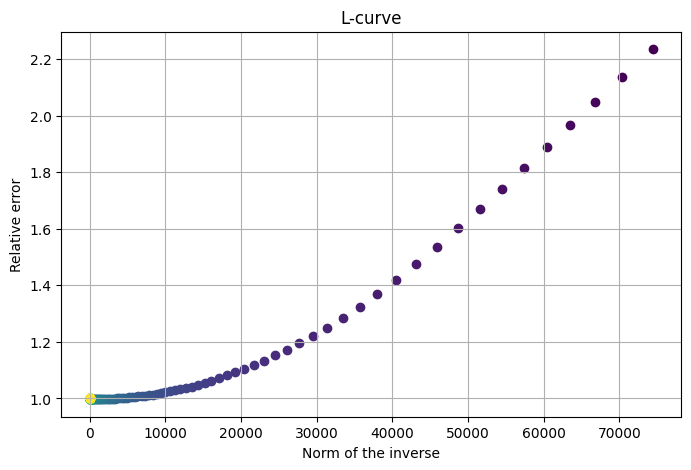

Images saved successfully.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + r * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    # Tamaño de la matriz
    n = 1000

    # RANGO MODIFICADO: ahora hasta x = 5
    # (antes era hasta 0)
    regularization_values = np.linspace(-10, 5, 150)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # Análisis de errores

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error  (log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error (log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    print(
        f"Maximum alpha tested: {10**regularization_values[-1]:.6e}"
    )

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title(
        "Relative Error vs Regularization Parameter"
    )

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully.")

Save figures


In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Correlation Matrix

Simulation 1


Correlation matrix:
[[1.         0.02236823 0.68738105]
 [0.02236823 1.         0.74149075]
 [0.68738105 0.74149075 1.        ]]
Condition number: 77727432102.36147

Execution time: 0.0473 seconds

--- Optimal Regularization ---
Minimum relative error: 5.773503e-01
log10(alpha_opt) = -3.434343
alpha_opt = 3.678380e-04


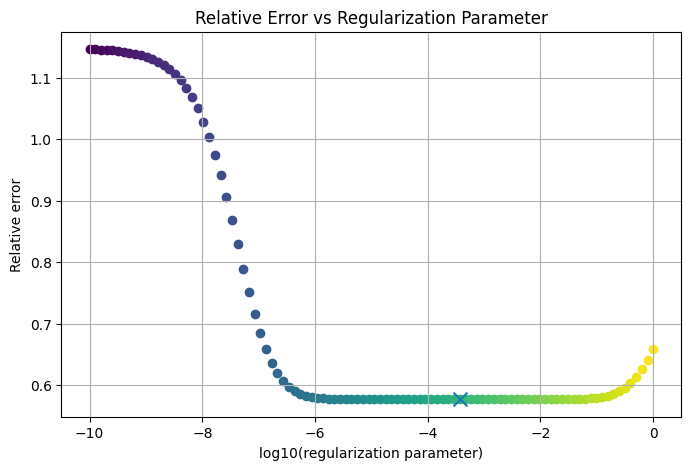

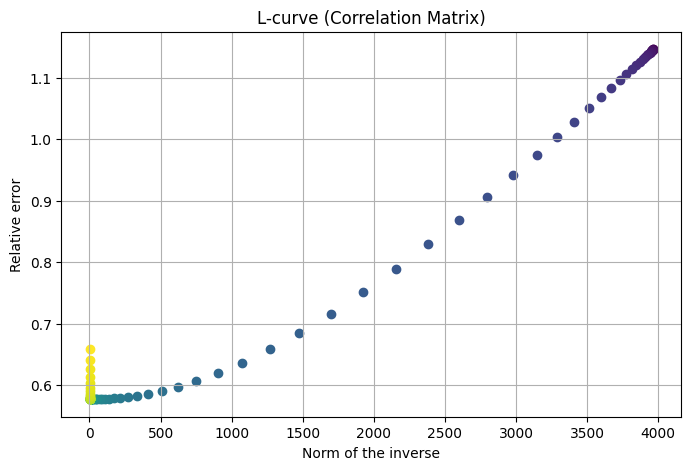


Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    X2 = np.random.randn(n_samples)
    epsilon = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon  # Strong linear dependence

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    C = generate_correlated_data()
    print("Correlation matrix:")
    print(C)
    print("Condition number:", np.linalg.cond(C))

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_norms = []
        for _ in range(num_trials):
            r = 10**(-3)
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, 10**reg)
            error = np.linalg.norm(A_inv_tik @ C - I) / np.linalg.norm(I)
            norm_inv = np.linalg.norm(A_inv_tik)
            trial_errors.append(error)
            trial_norms.append(norm_inv)
        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


if __name__ == "__main__":
    start_time = time.time()

    n = 3
    regularization_values = np.linspace(-10, 0, 100)
    errors, norms = compute_errors(n, regularization_values)

    execution_time = time.time() - start_time
    print(f"\nExecution time: {execution_time:.4f} seconds")

    # --------- Cálculo del mínimo ---------
    min_index = np.argmin(errors)
    min_error = errors[min_index]
    optimal_log_alpha = regularization_values[min_index]
    optimal_alpha = 10**optimal_log_alpha

    print("\n--- Optimal Regularization ---")
    print(f"Minimum relative error: {min_error:.6e}")
    print(f"log10(alpha_opt) = {optimal_log_alpha:.6f}")
    print(f"alpha_opt = {optimal_alpha:.6e}")

    colors = cm.viridis(np.linspace(0, 1, len(regularization_values)))

    # --------- FIGURA 1 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(regularization_values[i], errors[i], color=colors[i])
    plt.scatter(optimal_log_alpha, min_error, marker='x', s=100)  # Marca el mínimo
    plt.xlabel("log10(regularization parameter)")
    plt.ylabel("Relative error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()

    plt.savefig("correlation_relative_error.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --------- FIGURA 2 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(norms[i], errors[i], color=colors[i])
    plt.xlabel("Norm of the inverse")
    plt.ylabel("Relative error")
    plt.title("L-curve (Correlation Matrix)")
    plt.grid()

    plt.savefig("correlation_L_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print("\nImages saved successfully in the Colab environment.")

save figures



In [ ]:
from google.colab import files
files.download("correlation_relative_error.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("correlation_L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 2


Correlation matrix:
[[ 1.          0.03049424  0.69108655]
 [ 0.03049424  1.         -0.70136172]
 [ 0.69108655 -0.70136172  1.        ]]
Condition number: 76555973208.8374

--- Optimal Regularization ---
Minimum relative error: 5.773503e-01
log10(alpha_opt) = -3.737374
alpha_opt = 1.830738e-04


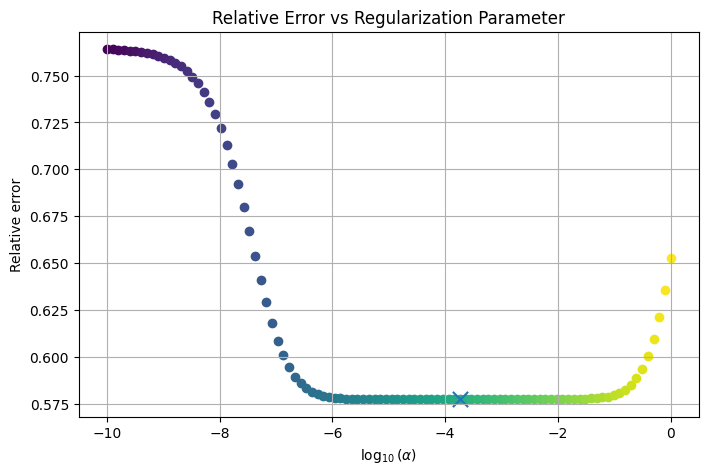

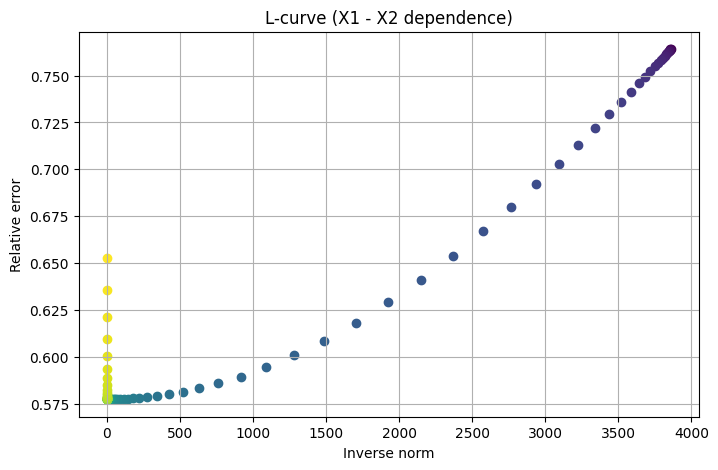


Execution time: 12.1530 seconds

Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    X2 = np.random.randn(n_samples)
    epsilon = noise * np.random.randn(n_samples)
    X3 = X1 - X2 + epsilon  # Strong linear dependence

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    C = generate_correlated_data()
    print("Correlation matrix:")
    print(C)
    print("Condition number:", np.linalg.cond(C))

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_norms = []
        for _ in range(num_trials):
            r = 10**(-3)
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, 10**reg)
            error = np.linalg.norm(A_inv_tik @ C - I) / np.linalg.norm(I)
            norm_inv = np.linalg.norm(A_inv_tik)
            trial_errors.append(error)
            trial_norms.append(norm_inv)
        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


if __name__ == "__main__":
    start_time = time.time()

    n = 3
    regularization_values = np.linspace(-10, 0, 100)
    errors, norms = compute_errors(n, regularization_values)

    # --------- Cálculo del mínimo ---------
    min_index = np.argmin(errors)
    min_error = errors[min_index]
    optimal_log_alpha = regularization_values[min_index]
    optimal_alpha = 10**optimal_log_alpha

    print("\n--- Optimal Regularization ---")
    print(f"Minimum relative error: {min_error:.6e}")
    print(f"log10(alpha_opt) = {optimal_log_alpha:.6f}")
    print(f"alpha_opt = {optimal_alpha:.6e}")

    colors = cm.viridis(np.linspace(0, 1, len(regularization_values)))

    # --------- FIGURA 1 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(regularization_values[i], errors[i], color=colors[i])
    plt.scatter(optimal_log_alpha, min_error, marker='x', s=120)  # Marca mínimo
    plt.xlabel(r"$\log_{10}(\alpha)$")
    plt.ylabel("Relative error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()

    plt.savefig("correlation_minus_relative_error.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --------- FIGURA 2 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(norms[i], errors[i], color=colors[i])
    plt.xlabel("Inverse norm")
    plt.ylabel("Relative error")
    plt.title("L-curve (X1 - X2 dependence)")
    plt.grid()

    plt.savefig("correlation_minus_L_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    end_time = time.time()
    print(f"\nExecution time: {end_time - start_time:.4f} seconds")
    print("\nImages saved successfully in the Colab environment.")

Save figures

In [ ]:
from google.colab import files
files.download("correlation_minus_relative_error.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("correlation_minus_L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 3


Correlation matrix:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
Condition number: 186816664198.11203

--- Optimal Regularization ---
Minimum relative error: 8.164966e-01
log10(alpha_opt) = -2.909091
alpha_opt = 1.232847e-03


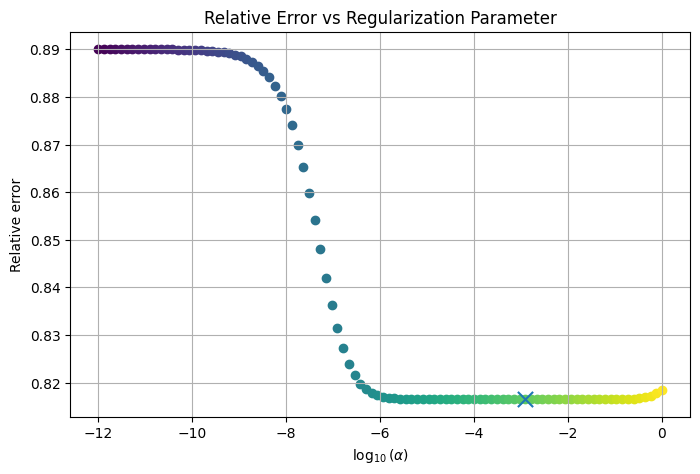

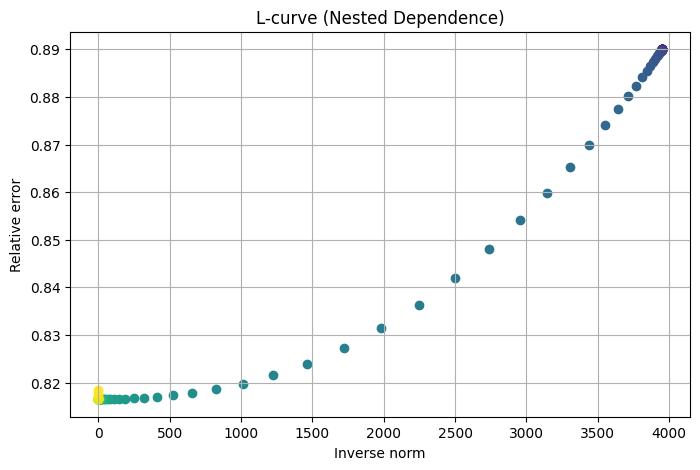


Execution time: 5.8925 seconds

Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    epsilon1 = noise * np.random.randn(n_samples)
    X2 = X1 + epsilon1
    epsilon2 = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon2

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I


def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    C = generate_correlated_data()
    print("Correlation matrix:")
    print(C)
    print("Condition number:", np.linalg.cond(C))

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_norms = []
        for _ in range(num_trials):
            r = 10**(-3)
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, 10**reg)
            error = np.linalg.norm(A_inv_tik @ C - I) / np.linalg.norm(I)
            norm_inv = np.linalg.norm(A_inv_tik)
            trial_errors.append(error)
            trial_norms.append(norm_inv)
        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


if __name__ == "__main__":
    start_time = time.time()

    n = 3
    regularization_values = np.linspace(-12, 0, 100)
    errors, norms = compute_errors(n, regularization_values)

    # --------- Cálculo del mínimo ---------
    min_index = np.argmin(errors)
    min_error = errors[min_index]
    optimal_log_alpha = regularization_values[min_index]
    optimal_alpha = 10**optimal_log_alpha

    print("\n--- Optimal Regularization ---")
    print(f"Minimum relative error: {min_error:.6e}")
    print(f"log10(alpha_opt) = {optimal_log_alpha:.6f}")
    print(f"alpha_opt = {optimal_alpha:.6e}")

    colors = cm.viridis(np.linspace(0, 1, len(regularization_values)))

    # --------- FIGURA 1 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(regularization_values[i], errors[i], color=colors[i])
    plt.scatter(optimal_log_alpha, min_error, marker='x', s=120)
    plt.xlabel(r"$\log_{10}(\alpha)$")
    plt.ylabel("Relative error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()

    plt.savefig("correlation_nested_relative_error.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --------- FIGURA 2 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(norms[i], errors[i], color=colors[i])
    plt.xlabel("Inverse norm")
    plt.ylabel("Relative error")
    plt.title("L-curve (Nested Dependence)")
    plt.grid()

    plt.savefig("correlation_nested_L_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    end_time = time.time()
    print(f"\nExecution time: {end_time - start_time:.4f} seconds")
    print("\nImages saved successfully in the Colab environment.")

Save figures


In [ ]:
from google.colab import files
files.download("correlation_nested_relative_error.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("correlation_nested_L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation with noise


Noise level: 0.04
Average condition number: 4.883e+03
log10(optimal alpha): -3.5152
Optimal alpha: 3.054e-04
Minimum relative error: 5.776e-01

Noise level: 0.05
Average condition number: 1.625e+03
log10(optimal alpha): -3.8788
Optimal alpha: 1.322e-04
Minimum relative error: 5.757e-01

Noise level: 0.08
Average condition number: 1.357e+03
log10(optimal alpha): -3.1515
Optimal alpha: 7.055e-04
Minimum relative error: 5.765e-01

Noise level: 0.1
Average condition number: 1.001e+03
log10(optimal alpha): -4.0000
Optimal alpha: 1.000e-04
Minimum relative error: 5.614e-01

Noise level: 0.2
Average condition number: 2.000e+02
log10(optimal alpha): -3.8788
Optimal alpha: 1.322e-04
Minimum relative error: 4.445e-01

Figure saved as: relative_error_vs_regularization.png


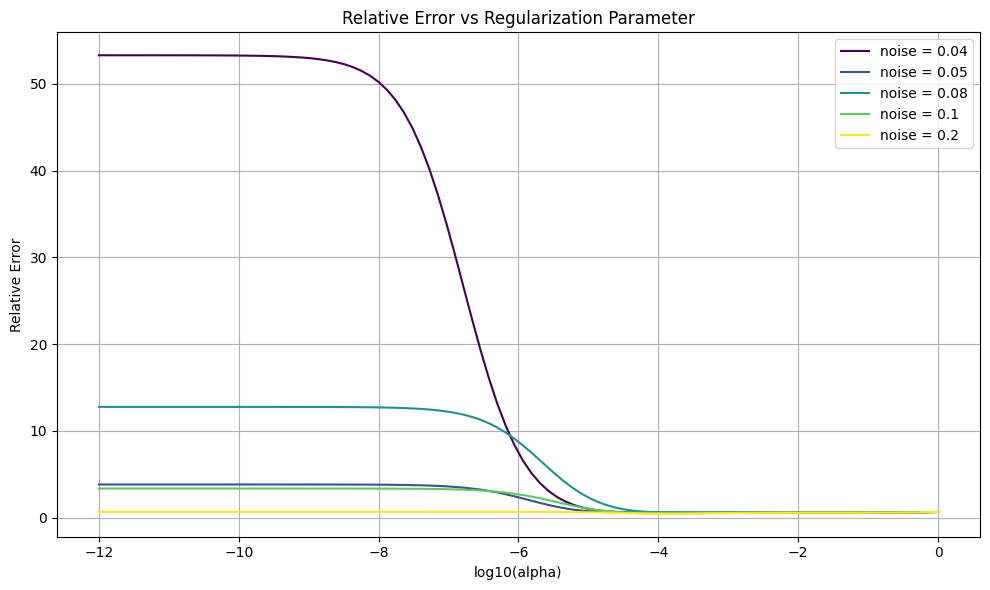

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    X2 = np.random.randn(n_samples)
    epsilon = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon  # Strong linear dependence

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10):
    errors = []
    cond_numbers = []

    # Matriz original
    C_org = generate_correlated_data(noise=noise)
    # Matriz para experimentar con ruido
    C = generate_correlated_data(noise=noise)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_conds = []
        alpha = 10**reg

        for _ in range(num_trials):
            r = 1e-3
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, alpha)
            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)
            trial_errors.append(error)

            # Guardar número de condición de A
            trial_conds.append(np.linalg.cond(A))

        # Promedio sobre los trials
        errors.append(np.mean(trial_errors))
        cond_numbers.append(np.mean(trial_conds))

    return np.array(errors), np.array(cond_numbers)


if __name__ == "__main__":
    n = 3
    regularization_values = np.linspace(-12, 0, 100)
    noise_levels = [0.04, 0.05, 0.08, 0.1, 0.2]
    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):
        errors, conds = compute_errors(n, regularization_values, noise=noise)

        min_index = np.argmin(errors)
        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        # Imprimir resumen
        print(f"Noise level: {noise}")
        print(f"Average condition number: {np.mean(conds):.3e}")
        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}\n")

        # Guardar tabla para exportar a LaTeX si quieres
        # Puedes descomentar estas líneas para ver la tabla completa
        # import pandas as pd
        # df = pd.DataFrame({
        #     'log10_alpha': regularization_values,
        #     'relative_error': errors,
        #     'condition_number': conds
        # })
        # print(df)

        plt.plot(regularization_values, errors,
                 label=f"noise = {noise}",
                 color=colors[i])

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()
    plt.legend()
    plt.tight_layout()

    # 🔹 Guardar imagen
    filename = "relative_error_vs_regularization.png"
    plt.savefig(filename, dpi=300)
    print(f"Figure saved as: {filename}")

    plt.show()

Save figures


In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Another simulation with noise



Noise level: 0.04
Condition number: 1.138e+04
log10(optimal alpha): -2.6667
Optimal alpha: 2.154e-03
Minimum relative error: 8.165e-01


Noise level: 0.05
Condition number: 7.483e+03
log10(optimal alpha): -2.3030
Optimal alpha: 4.977e-03
Minimum relative error: 8.165e-01


Noise level: 0.08
Condition number: 2.720e+03
log10(optimal alpha): -1.9394
Optimal alpha: 1.150e-02
Minimum relative error: 8.165e-01


Noise level: 0.1
Condition number: 1.913e+03
log10(optimal alpha): -1.6970
Optimal alpha: 2.009e-02
Minimum relative error: 8.165e-01


Noise level: 0.2
Condition number: 4.531e+02
log10(optimal alpha): -1.0909
Optimal alpha: 8.111e-02
Minimum relative error: 8.165e-01

Figure saved as: relative_error_vs_regularization_noise_levels.png


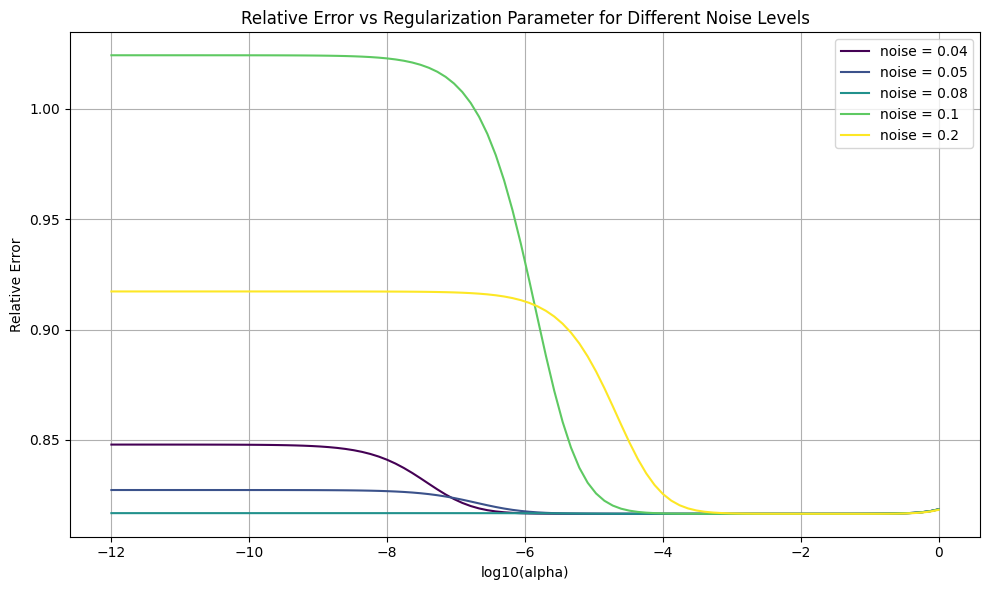

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_correlated_data(n_samples=2000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    epsilon1 = noise * np.random.randn(n_samples)
    X2 = X1 + epsilon1
    epsilon2 = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon2

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10):
    errors = []

    C_org = generate_correlated_data()
    C = generate_correlated_data(noise=noise)

    cond_number = np.linalg.cond(C)
    print(f"\nNoise level: {noise}")
    print(f"Condition number: {cond_number:.3e}")

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        alpha = 10**reg

        for _ in range(num_trials):
            r = 10**(-3)
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, alpha)
            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)
            trial_errors.append(error)

        errors.append(np.mean(trial_errors))

    return np.array(errors)


if __name__ == "__main__":
    n = 3
    regularization_values = np.linspace(-12, 0, 100)
    noise_levels = [0.04, 0.05, 0.08, 0.1, 0.2]

    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):
        errors = compute_errors(n, regularization_values, noise=noise)

        min_index = np.argmin(errors)
        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}\n")

        plt.plot(
            regularization_values,
            errors,
            label=f"noise = {noise}",
            color=colors[i]
        )

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")
    plt.title("Relative Error vs Regularization Parameter for Different Noise Levels")

    plt.grid()
    plt.legend()
    plt.tight_layout()

    # Guardar figura
    filename = "relative_error_vs_regularization_noise_levels.png"
    plt.savefig(filename, dpi=300)

    print(f"Figure saved as: {filename}")

    plt.show()

Save figures

In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization_noise_levels.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Large simulation with noise


Noise level: 0.04
Condition number: 2.741e+04
log10(optimal alpha): -3.7374
Optimal alpha: 1.831e-04
Minimum relative error: 5.161e-02


Noise level: 0.05
Condition number: 1.754e+04
log10(optimal alpha): -3.6364
Optimal alpha: 2.310e-04
Minimum relative error: 5.169e-02


Noise level: 0.08
Condition number: 6.849e+03
log10(optimal alpha): -3.4343
Optimal alpha: 3.678e-04
Minimum relative error: 5.213e-02


Noise level: 0.1
Condition number: 4.385e+03
log10(optimal alpha): -3.3333
Optimal alpha: 4.642e-04
Minimum relative error: 5.269e-02


Noise level: 0.2
Condition number: 1.106e+03
log10(optimal alpha): -2.9293
Optimal alpha: 1.177e-03
Minimum relative error: 5.941e-02

Figure saved as: relative_error_vs_regularization_large_matrix.png


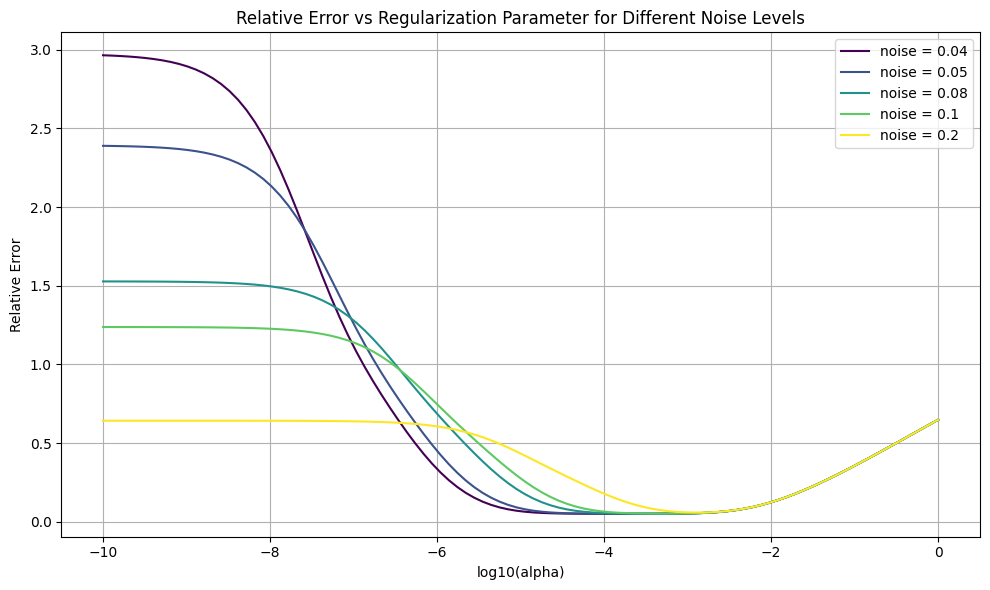

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_large_correlated_data(n_vars=50, n_samples=2000, noise=0.00001, seed=None):
    """
    Generate simulated data with correlations in a few variables
    and many others independent.
    """
    if seed is not None:
        np.random.seed(seed)

    base = np.random.randn(n_samples, n_vars)

    epsilon1 = noise * np.random.randn(n_samples)
    epsilon2 = noise * np.random.randn(n_samples)

    base[:, 1] = base[:, 0] + epsilon1
    base[:, 2] = base[:, 0] + base[:, 1] + epsilon2

    data = base
    correlation_matrix = np.corrcoef(data, rowvar=False)

    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10):

    errors = []

    C_org = generate_large_correlated_data(n_vars=n, seed=42)
    C = generate_large_correlated_data(n_vars=n, noise=noise, seed=42)

    cond_number = np.linalg.cond(C)

    print(f"\nNoise level: {noise}")
    print(f"Condition number: {cond_number:.3e}")

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        alpha = 10**reg

        for _ in range(num_trials):

            r = 10**(-3)
            A = C + r * J

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)

            trial_errors.append(error)

        errors.append(np.mean(trial_errors))

    return np.array(errors)


if __name__ == "__main__":

    n = 1000
    regularization_values = np.linspace(-10, 0, 100)

    noise_levels = [0.04, 0.05, 0.08, 0.1, 0.2]

    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):

        errors = compute_errors(n, regularization_values, noise=noise)

        min_index = np.argmin(errors)

        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}\n")

        plt.plot(
            regularization_values,
            errors,
            label=f"noise = {noise}",
            color=colors[i]
        )

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")

    plt.title("Relative Error vs Regularization Parameter for Different Noise Levels")

    plt.grid()
    plt.legend()
    plt.tight_layout()

    filename = "relative_error_vs_regularization_large_matrix.png"

    plt.savefig(filename, dpi=300)

    print(f"Figure saved as: {filename}")

    plt.show()

Save figures


In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization_large_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Another form from correlation matrix

Simulation 1

Condition number of C: 2.446e+09

Results for noise = 0
log10(optimal alpha): -13.3333
Optimal alpha: 4.642e-14
Minimum relative error: 4.472e-01
Left extreme error: 7.888e+00
Right extreme error: 6.280e-01

Figure saved as: relative_error_vs_regularization_ill_conditioned_matrix.png


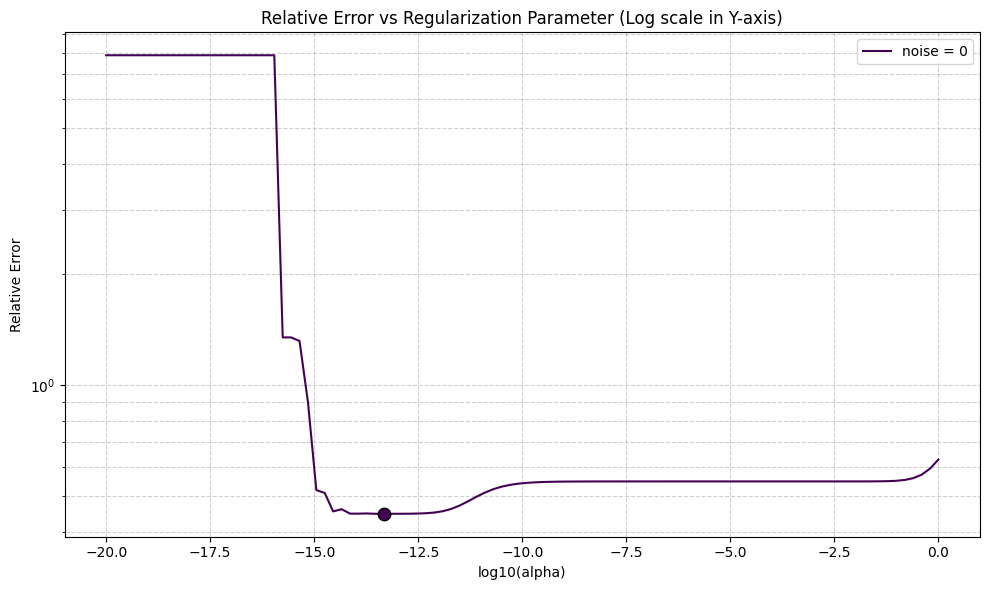

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_ill_conditioned_correlation_matrix(n, cond_number=1e5, seed=None):

    if seed is not None:
        np.random.seed(seed)

    Q, _ = np.linalg.qr(np.random.randn(n, n))

    eigvals = np.ones(n)
    eigvals[-1] = 5.0 / cond_number
    eigvals[-2] = 5.0 / cond_number
    eigvals[-3] = 1.0e-6

    C = Q @ np.diag(eigvals) @ Q.T

    std_devs = np.sqrt(np.diag(C))
    C = C / np.outer(std_devs, std_devs)

    cond_num = np.linalg.cond(C)

    print(f"Condition number of C: {cond_num:.3e}")

    return C


def inverse_by_tikhonov(A, alpha):

    n = A.shape[0]
    I = np.eye(n)

    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10, seed=None):

    errors = []

    C_org = generate_ill_conditioned_correlation_matrix(n, cond_number=1e10, seed=seed)

    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        alpha = 10**reg

        for _ in range(num_trials):

            perturb = noise * np.random.randn(n, n)
            perturb = (perturb + perturb.T) / 2

            A = C_org + 1*perturb

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)

            trial_errors.append(error)

        errors.append(np.mean(trial_errors))

    return np.array(errors)


if __name__ == "__main__":

    n = 10

    regularization_values = np.linspace(-20, 0, 100)

    noise_levels = [0]

    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):

        errors = compute_errors(n, regularization_values, noise=noise, seed=42)

        min_index = np.argmin(errors)

        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        error_left = errors[0]
        error_right = errors[-1]

        print("\nResults for noise =", noise)

        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}")

        print(f"Left extreme error: {error_left:.3e}")
        print(f"Right extreme error: {error_right:.3e}")

        plt.plot(
            regularization_values,
            errors,
            label=f"noise = {noise}",
            color=colors[i]
        )

        plt.scatter(
            optimal_log_alpha,
            min_error,
            color=colors[i],
            marker='o',
            edgecolors='black',
            s=80,
            zorder=3
        )

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")

    plt.yscale("log")

    plt.title("Relative Error vs Regularization Parameter (Log scale in Y-axis)")

    plt.grid(True, which="both", linestyle="--", alpha=0.6)

    plt.legend()

    plt.tight_layout()

    filename = "relative_error_vs_regularization_ill_conditioned_matrix.png"

    plt.savefig(filename, dpi=300)

    print(f"\nFigure saved as: {filename}")

    plt.show()

Save figures

In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization_ill_conditioned_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 2


Condition number of C: 2.023e+09

Results for noise = 0
log10(optimal alpha): -13.3333
Optimal alpha: 4.642e-14
Minimum relative error: 3.654e-02
Left extreme error: 3.022e+01
Right extreme error: 5.005e-01

Figure saved as: relative_error_vs_regularization_large_ill_conditioned_matrix.png


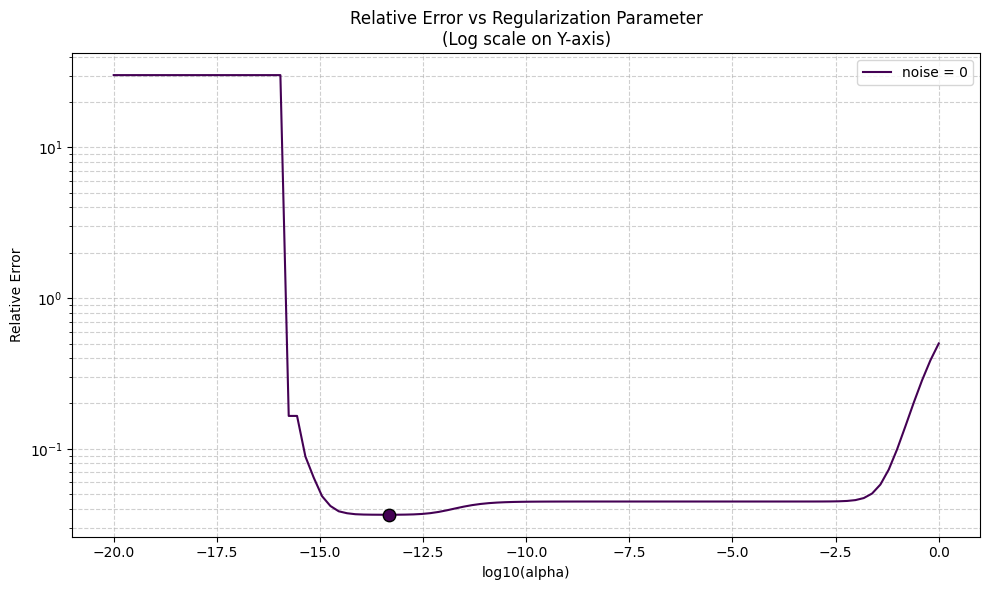

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_ill_conditioned_correlation_matrix(n, cond_number=1e5, seed=None):

    if seed is not None:
        np.random.seed(seed)

    Q, _ = np.linalg.qr(np.random.randn(n, n))

    eigvals = np.ones(n)
    eigvals[-1] = 5.0 / cond_number
    eigvals[-2] = 5.0 / cond_number
    eigvals[-3] = 1.0e-6

    C = Q @ np.diag(eigvals) @ Q.T

    std_devs = np.sqrt(np.diag(C))
    C = C / np.outer(std_devs, std_devs)

    cond_num = np.linalg.cond(C)

    print(f"Condition number of C: {cond_num:.3e}")

    return C


def inverse_by_tikhonov(A, alpha):

    n = A.shape[0]
    I = np.eye(n)

    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10, seed=None):

    errors = []

    C_org = generate_ill_conditioned_correlation_matrix(
        n,
        cond_number=1e10,
        seed=seed
    )

    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []

        alpha = 10**reg

        for _ in range(num_trials):

            perturb = noise * np.random.randn(n, n)
            perturb = (perturb + perturb.T) / 2

            A = C_org + perturb

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)

            trial_errors.append(error)

        errors.append(np.mean(trial_errors))

    return np.array(errors)


if __name__ == "__main__":

    n = 1500

    regularization_values = np.linspace(-20, 0, 100)

    noise_levels = [0]

    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):

        errors = compute_errors(
            n,
            regularization_values,
            noise=noise,
            seed=42
        )

        min_index = np.argmin(errors)

        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        error_left = errors[0]
        error_right = errors[-1]

        print("\nResults for noise =", noise)

        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")

        print(f"Minimum relative error: {min_error:.3e}")

        print(f"Left extreme error: {error_left:.3e}")
        print(f"Right extreme error: {error_right:.3e}")

        plt.plot(
            regularization_values,
            errors,
            label=f"noise = {noise}",
            color=colors[i]
        )

        plt.scatter(
            optimal_log_alpha,
            min_error,
            color=colors[i],
            marker='o',
            edgecolors='black',
            s=80,
            zorder=3
        )

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")

    plt.yscale("log")

    plt.title(
        "Relative Error vs Regularization Parameter\n(Log scale on Y-axis)"
    )

    plt.grid(True, which="both", linestyle="--", alpha=0.6)

    plt.legend()

    plt.tight_layout()

    filename = "relative_error_vs_regularization_large_ill_conditioned_matrix.png"

    plt.savefig(filename, dpi=300)

    print(f"\nFigure saved as: {filename}")

    plt.show()

Save figures

In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization_large_ill_conditioned_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

simulation 3D




--- Independent case ---
Covariance matrix:
 [[ 0.95886385 -0.03945949  0.02131041]
 [-0.03945949  0.99491523 -0.01098604]
 [ 0.02131041 -0.01098604  0.96718232]]
Correlation matrix:
 [[ 1.         -0.04039987  0.02212886]
 [-0.04039987  1.         -0.01119938]
 [ 0.02212886 -0.01119938  1.        ]]


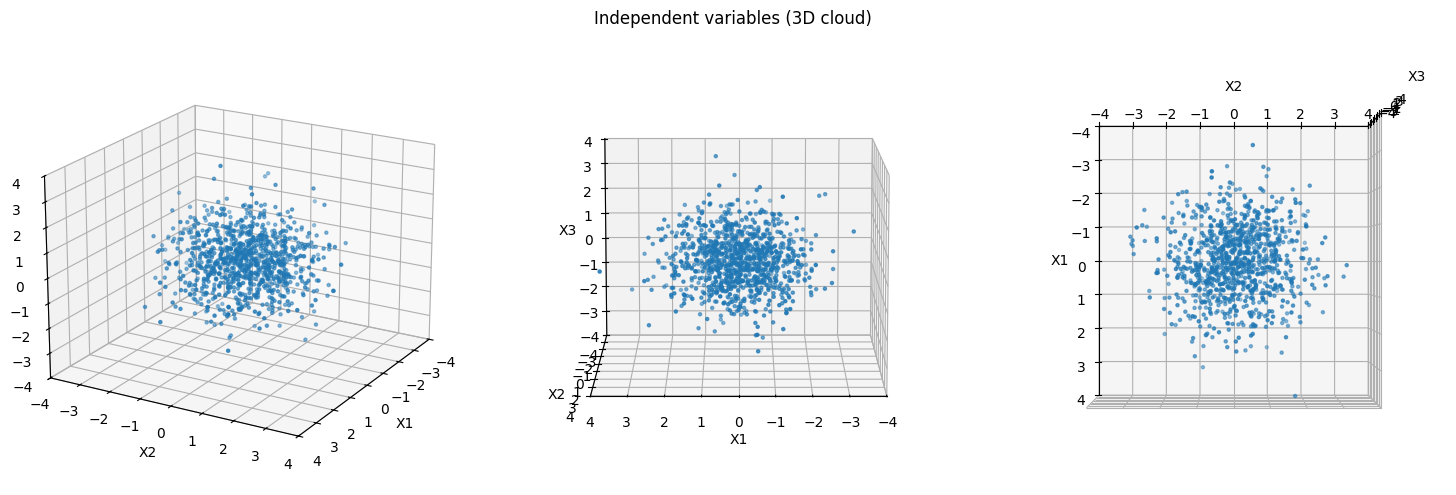


--- Plane case ---
Covariance matrix:
 [[ 0.95886385 -0.03945949  0.9215354 ]
 [-0.03945949  0.99491523  0.95435714]
 [ 0.9215354   0.95435714  1.8865968 ]]
Correlation matrix:
 [[ 1.         -0.04039987  0.68516316]
 [-0.04039987  1.          0.69659177]
 [ 0.68516316  0.69659177  1.        ]]


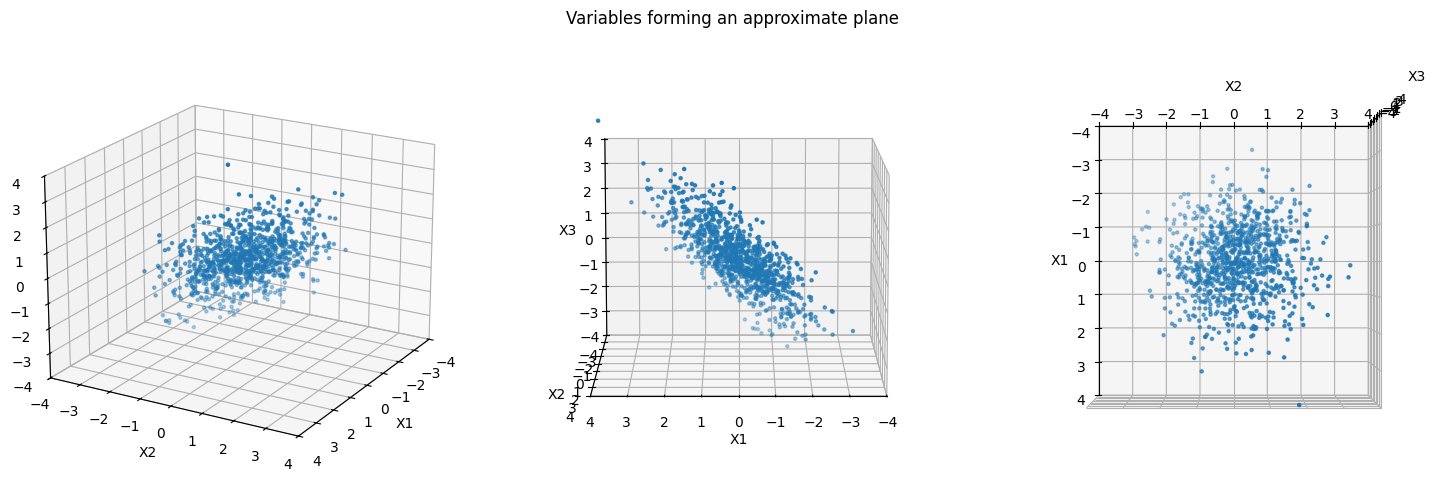


--- Fully correlated case (no noise) ---
Covariance matrix:
 [[0.95886385 0.95886385 0.95886385]
 [0.95886385 0.95886385 0.95886385]
 [0.95886385 0.95886385 0.95886385]]
Correlation matrix:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


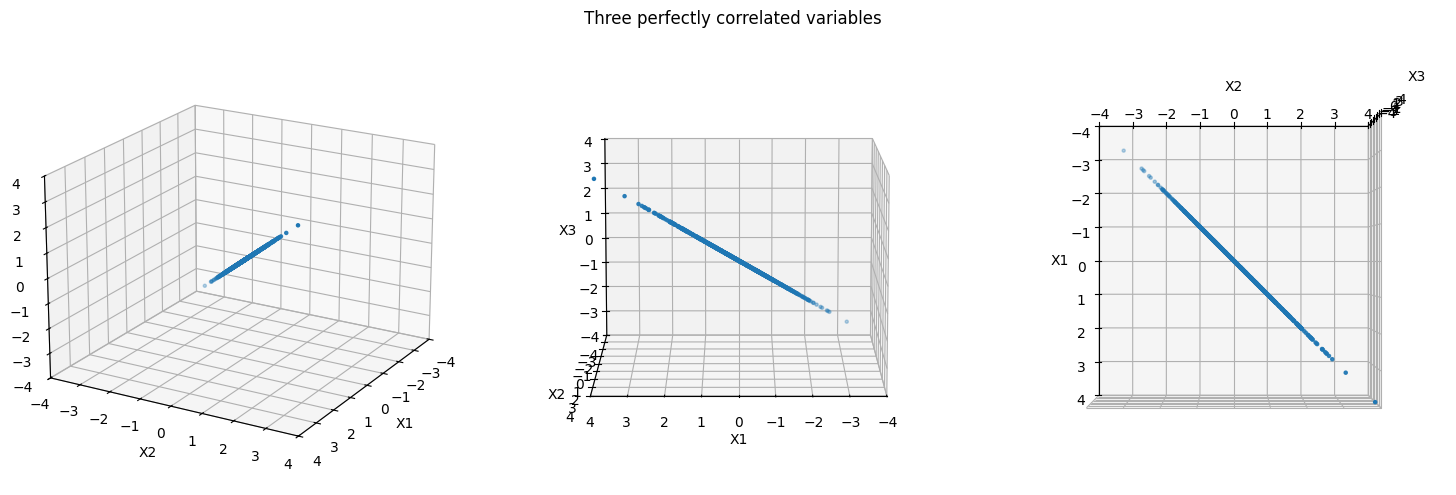


--- Noise level = 0.01 ---
Covariance matrix:
 [[0.95817416 0.95868126 0.95832967]
 [0.95868126 0.95938678 0.95894516]
 [0.95832967 0.95894516 0.95870139]]
Correlation matrix:
 [[1.         0.99989673 0.99988725]
 [0.99989673 1.         0.99989691]
 [0.99988725 0.99989691 1.        ]]


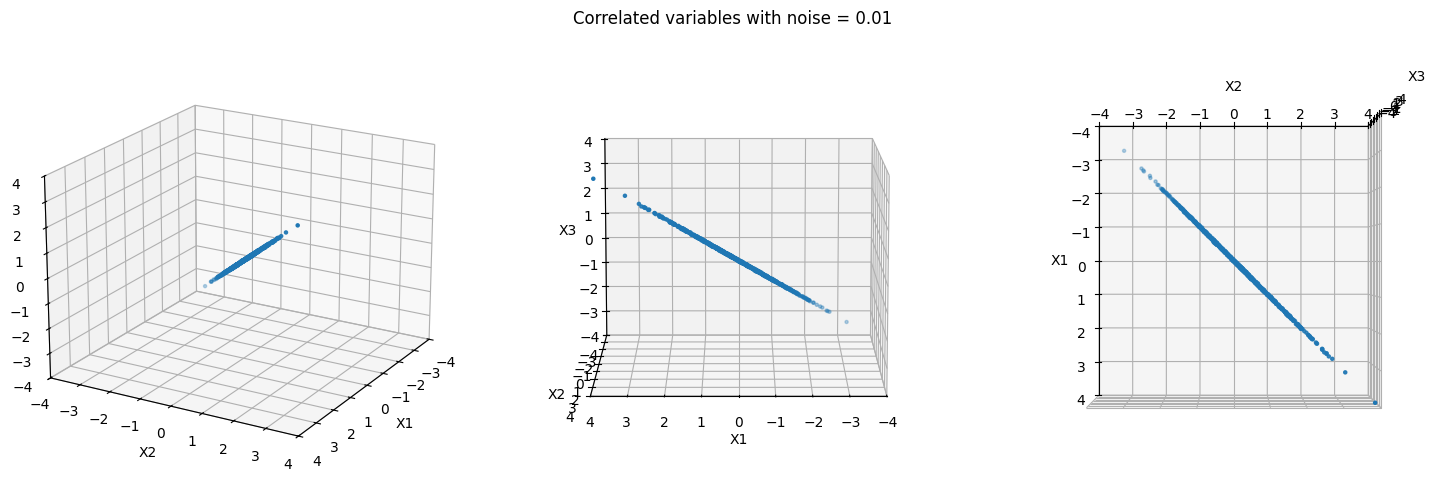


--- Noise level = 0.1 ---
Covariance matrix:
 [[0.96092111 0.95693908 0.9530177 ]
 [0.95693908 0.97279776 0.95987313]
 [0.9530177  0.95987313 0.96673423]]
Correlation matrix:
 [[1.         0.98975829 0.98878883]
 [0.98975829 1.         0.98980354]
 [0.98878883 0.98980354 1.        ]]


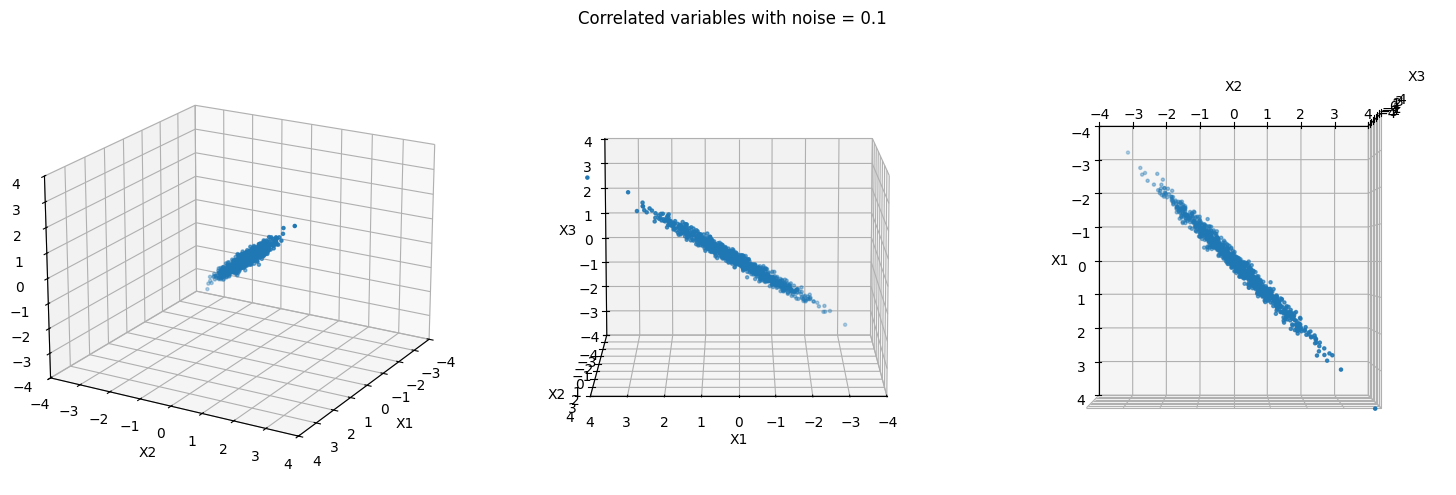


--- Noise level = 0.3 ---
Covariance matrix:
 [[1.02473053 0.95243038 0.93796306]
 [0.95243038 1.05869651 0.96319998]
 [0.93796306 0.96319998 1.04577507]]
Correlation matrix:
 [[1.         0.91441357 0.90607001]
 [0.91441357 1.         0.91540142]
 [0.90607001 0.91540142 1.        ]]


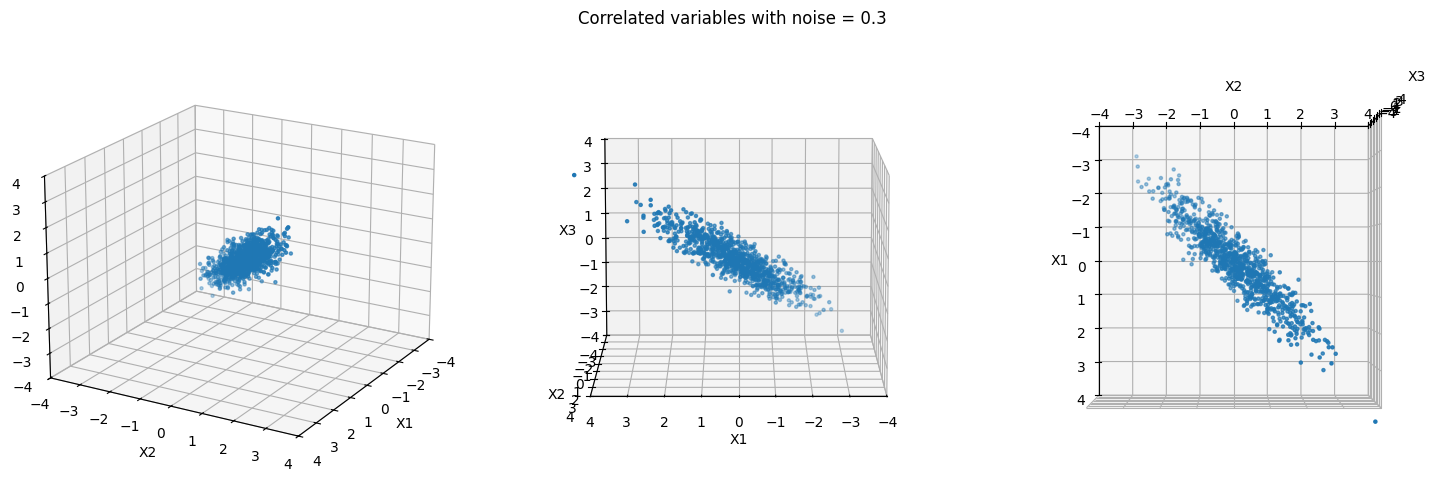


--- Noise level = 0.6 ---
Covariance matrix:
 [[1.26968195 0.94401943 0.90697527]
 [0.94401943 1.33262198 0.97146101]
 [0.90697527 0.97146101 1.3225865 ]]
Correlation matrix:
 [[1.         0.72573818 0.6998999 ]
 [0.72573818 1.         0.73174514]
 [0.6998999  0.73174514 1.        ]]


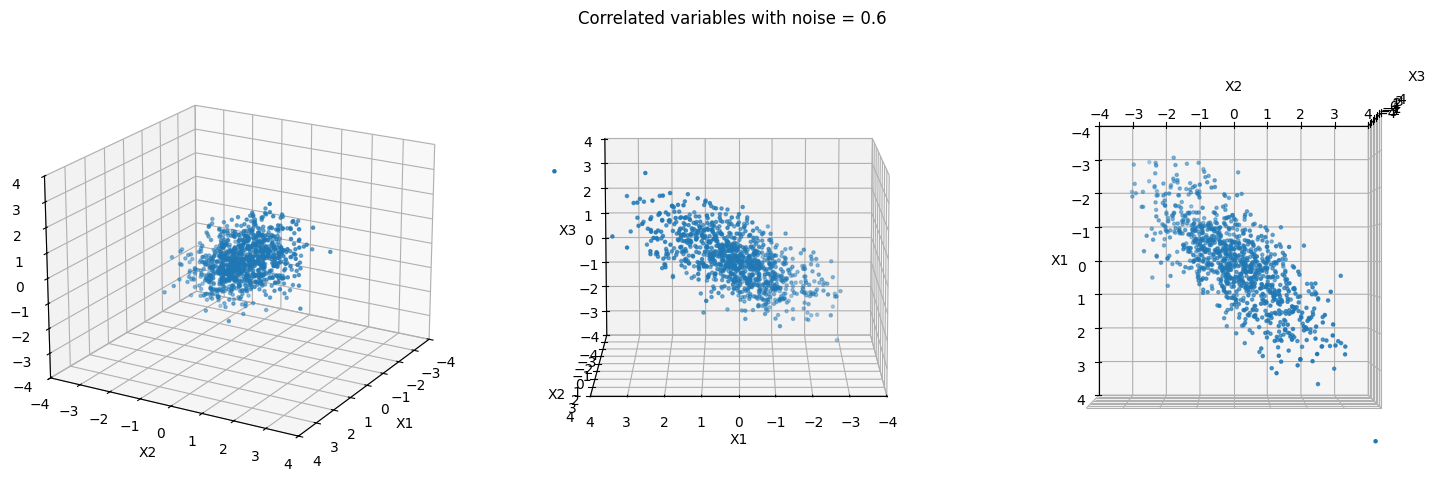


--- Noise level = 0.9 ---
Covariance matrix:
 [[1.69371811 0.93363099 0.86590049]
 [0.93363099 1.78064027 0.98364695]
 [0.86590049 0.98364695 1.78929815]]
Correlation matrix:
 [[1.         0.53760908 0.49740033]
 [0.53760908 1.         0.55107384]
 [0.49740033 0.55107384 1.        ]]


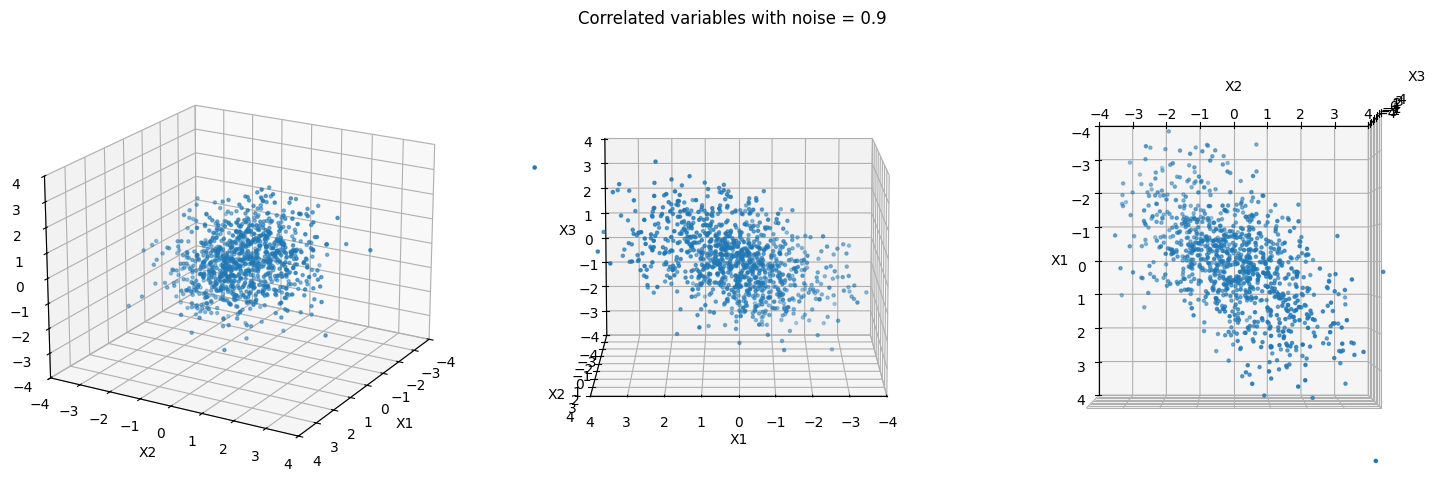


All images saved successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# GENERADOR GENERAL
# =========================================================
def generate_data(case="independent",
                  n_samples=1000,
                  noise=0.0,
                  seed=42):

    np.random.seed(seed)

    # -----------------------------------------------------
    # CASO 1: VARIABLES INDEPENDIENTES
    # -----------------------------------------------------
    if case == "independent":

        X1 = np.random.randn(n_samples)
        X2 = np.random.randn(n_samples)
        X3 = np.random.randn(n_samples)

    # -----------------------------------------------------
    # CASO 2: VARIABLES EN UN PLANO
    # X3 depende de X1 y X2
    # -----------------------------------------------------
    elif case == "plane":

        X1 = np.random.randn(n_samples)
        X2 = np.random.randn(n_samples)

        epsilon = noise * np.random.randn(n_samples)

        X3 = X1 + X2 + epsilon

    # -----------------------------------------------------
    # CASO 3: VARIABLES TOTALMENTE CORRELACIONADAS
    # SIN RUIDO:
    # X1 = X2 = X3
    # -----------------------------------------------------
    elif case == "fully_correlated":

        Z = np.random.randn(n_samples)

        # Sin ruido
        X1 = Z
        X2 = Z
        X3 = Z

    else:
        raise ValueError("Caso no válido.")

    # -----------------------------------------------------
    # MATRICES
    # -----------------------------------------------------
    data = np.vstack((X1, X2, X3)).T

    cov_matrix = np.cov(data, rowvar=False)
    corr_matrix = np.corrcoef(data, rowvar=False)

    return data, cov_matrix, corr_matrix


# =========================================================
# GRAFICADOR MULTI-ÁNGULO
# =========================================================
def plot_multiple_views(data, title, filename):

    fig = plt.figure(figsize=(15, 5))

    views = [
        (20, 30),   # vista oblicua
        (10, 90),   # vista lateral
        (90, 0)     # vista superior
    ]

    for i, (elev, azim) in enumerate(views):

        ax = fig.add_subplot(1, 3, i + 1, projection='3d')

        ax.scatter(
            data[:, 0],
            data[:, 1],
            data[:, 2],
            s=5
        )

        ax.view_init(elev=elev, azim=azim)

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("X3")

        # Misma escala en todos los ejes
        lim = 4

        ax.set_xlim([-lim, lim])
        ax.set_ylim([-lim, lim])
        ax.set_zlim([-lim, lim])

    fig.suptitle(title)

    plt.tight_layout()

    plt.savefig(filename, dpi=300)

    plt.show()
    plt.close()


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    # =====================================================
    # CASO INDEPENDIENTE
    # =====================================================
    data, cov, corr = generate_data(
        case="independent"
    )

    print("\n--- Independent case ---")
    print("Covariance matrix:\n", cov)
    print("Correlation matrix:\n", corr)

    plot_multiple_views(
        data,
        "Independent variables (3D cloud)",
        "independent_cloud.png"
    )

    # =====================================================
    # CASO PLANO
    # =====================================================
    data, cov, corr = generate_data(
        case="plane",
        noise=0.1
    )

    print("\n--- Plane case ---")
    print("Covariance matrix:\n", cov)
    print("Correlation matrix:\n", corr)

    plot_multiple_views(
        data,
        "Variables forming an approximate plane",
        "plane_cloud.png"
    )

    # =====================================================
    # CASO TOTALMENTE CORRELACIONADO SIN RUIDO
    # =====================================================
    data, cov, corr = generate_data(
        case="fully_correlated"
    )

    print("\n--- Fully correlated case (no noise) ---")
    print("Covariance matrix:\n", cov)
    print("Correlation matrix:\n", corr)

    plot_multiple_views(
        data,
        "Three perfectly correlated variables",
        "fully_correlated.png"
    )

    # =====================================================
    # EFECTO DEL RUIDO
    # =====================================================
    noise_levels = [0.01, 0.1, 0.3, 0.6, 0.9]

    for noise in noise_levels:

        np.random.seed(42)

        # Variable latente común
        Z = np.random.randn(1000)

        # Ruido independiente
        epsilon1 = noise * np.random.randn(1000)
        epsilon2 = noise * np.random.randn(1000)
        epsilon3 = noise * np.random.randn(1000)

        X1 = Z + epsilon1
        X2 = Z + epsilon2
        X3 = Z + epsilon3

        data = np.vstack((X1, X2, X3)).T

        cov = np.cov(data, rowvar=False)
        corr = np.corrcoef(data, rowvar=False)

        print(f"\n--- Noise level = {noise} ---")
        print("Covariance matrix:\n", cov)
        print("Correlation matrix:\n", corr)

        plot_multiple_views(
            data,
            f"Correlated variables with noise = {noise}",
            f"fully_correlated_noise_{noise}.png"
        )

    print("\nAll images saved successfully.")

Save figures

In [ ]:
# =========================================================
# COMPRIMIR TODAS LAS IMÁGENES EN UN ZIP (GOOGLE COLAB)
# =========================================================

import zipfile
from google.colab import files

# Nombre del archivo ZIP
zip_filename = "generated_images.zip"

# Lista de imágenes generadas
image_files = [
    "independent_cloud.png",
    "plane_cloud.png",
    "fully_correlated.png",
    "fully_correlated_noise_0.01.png",
    "fully_correlated_noise_0.1.png",
    "fully_correlated_noise_0.3.png",
    "fully_correlated_noise_0.6.png",
    "fully_correlated_noise_1.0.png"
]

# Crear ZIP
with zipfile.ZipFile(zip_filename, "w") as zipf:
    for file in image_files:
        zipf.write(file)

print(f"{zip_filename} creado correctamente.")

# Descargar automáticamente
files.download(zip_filename)

generated_images.zip creado correctamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ejemplo final

In [ ]:
import numpy as np
import scipy.stats as stats

# -------------------------
# 1. Generate data
# -------------------------
def generate_data(n=1000, noise=0.05, seed=42):
    np.random.seed(seed)

    X1 = np.random.randn(n)
    X2 = np.random.randn(n)
    epsilon = noise * np.random.randn(n)

    X3 = X1 + X2 + epsilon

    X = np.vstack((X1, X2, X3)).T
    return X


# -------------------------
# 2. Tikhonov inverse
# -------------------------
def tikhonov_inverse(Sigma, alpha):
    d = Sigma.shape[0]
    I = np.eye(d)
    return np.linalg.inv(Sigma + alpha * I)


# -------------------------
# 3. Find optimal alpha
# -------------------------
def find_optimal_alpha(Sigma, alphas):
    errors = []

    I = np.eye(Sigma.shape[0])

    for a in alphas:
        Sigma_inv = tikhonov_inverse(Sigma, a)
        error = np.linalg.norm(Sigma_inv @ Sigma - I)
        errors.append(error)

    errors = np.array(errors)
    idx = np.argmin(errors)

    return alphas[idx], errors[idx]


# -------------------------
# 4. Confidence intervals
# -------------------------
def confidence_intervals(X, Sigma_inv, alpha_level=0.05):

    n, d = X.shape
    X_bar = np.mean(X, axis=0)

    # Chi-square critical value
    C = stats.chi2.ppf(1 - alpha_level, df=d)

    intervals = []

    for i in range(d):

        # Diagonal of inverse matrix
        alpha_ii = np.linalg.inv(Sigma_inv)[i, i]

        radius = np.sqrt(C * alpha_ii / n)

        intervals.append((X_bar[i] - radius, X_bar[i] + radius))

    return X_bar, intervals


# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":

    # Generate data
    X = generate_data(n=1000, noise=0.05)

    # Covariance and correlation
    Sigma = np.cov(X, rowvar=False)
    Corr = np.corrcoef(X, rowvar=False)

    print("\nCovariance matrix:\n", Sigma)
    print("\nCorrelation matrix:\n", Corr)

    # Regularization search
    alpha_grid = np.logspace(-8, 0, 100)

    alpha_opt, min_error = find_optimal_alpha(Sigma, alpha_grid)

    print("\nOptimal alpha:", alpha_opt)
    print("Minimum inversion error:", min_error)

    # Regularized inverse
    Sigma_inv_reg = tikhonov_inverse(Sigma, alpha_opt)

    # Confidence intervals
    X_bar, intervals = confidence_intervals(X, Sigma_inv_reg)

    print("\nSample means:", X_bar)

    print("\n95% Confidence intervals:")
    for i, interval in enumerate(intervals):
        print(f"mu_{i+1}: ({interval[0]:.4f}, {interval[1]:.4f})")


Covariance matrix:
 [[ 0.95886385 -0.03945949  0.92046988]
 [-0.03945949  0.99491523  0.95490644]
 [ 0.92046988  0.95490644  1.8783105 ]]

Correlation matrix:
 [[ 1.         -0.04039987  0.68587886]
 [-0.04039987  1.          0.69852843]
 [ 0.68587886  0.69852843  1.        ]]

Optimal alpha: 1e-08
Minimum inversion error: 1.2426360312828553e-05

Sample means: [0.01933206 0.07083624 0.09046   ]

95% Confidence intervals:
mu_1: (-0.0672, 0.1059)
mu_2: (-0.0173, 0.1590)
mu_3: (-0.0307, 0.2116)


Aplication



Optimal alpha: 1e-08
Minimum error: 1.2426360312828553e-05

Chi-square constant: 6.251388631170325

Estimated mean vector:
[0.01933206 0.07083624 0.09046   ]

Intervals from theorem:
X_1: (-2.4290, 2.4676)
X_2: (-2.4231, 2.5647)
X_3: (-3.3362, 3.5171)

Points inside: 965
Points outside: 35
Percentage inside: 96.5


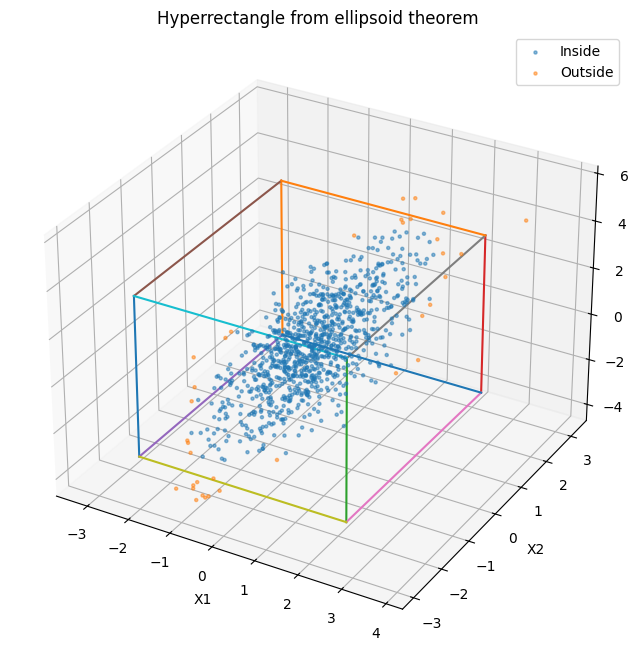

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# =========================================================
# 1. Generate correlated data
# =========================================================
def generate_data(n=10000, noise=0.05, seed=42):

    np.random.seed(seed)

    X1 = np.random.randn(n)
    X2 = np.random.randn(n)

    epsilon = noise * np.random.randn(n)

    # Variables approximately on a plane
    X3 = X1 + X2 + epsilon

    X = np.vstack((X1, X2, X3)).T

    return X


# =========================================================
# 2. Tikhonov inverse
# =========================================================
def tikhonov_inverse(Sigma, alpha):

    d = Sigma.shape[0]

    I = np.eye(d)

    return np.linalg.inv(Sigma + alpha * I)


# =========================================================
# 3. Find optimal alpha
# =========================================================
def find_optimal_alpha(Sigma, alphas):

    errors = []

    I = np.eye(Sigma.shape[0])

    for a in alphas:

        Sigma_inv = tikhonov_inverse(Sigma, a)

        error = np.linalg.norm(
            Sigma_inv @ Sigma - I
        )

        errors.append(error)

    errors = np.array(errors)

    idx = np.argmin(errors)

    return alphas[idx], errors[idx]


# =========================================================
# 4. Hyperrectangle from ellipsoid theorem
#
# Region:
#
# (x-mu)^T Sigma^{-1} (x-mu) <= C
#
# The theorem gives the circumscribed rectangle:
#
# x_i = mu_i ± sqrt(C * Sigma_ii)
# =========================================================
def probability_intervals(
        X,
        Sigma_reg,
        alpha_level=0.05):

    n, d = X.shape

    # Estimated mean
    mu_hat = np.mean(X, axis=0)

    # Chi-square critical value
    C = stats.chi2.ppf(
        1 - alpha_level,
        df=d
    )

    intervals = []

    for i in range(d):

        sigma_ii = Sigma_reg[i, i]

        # Radius from theorem
        radius = np.sqrt(
            C * sigma_ii
        )

        intervals.append((
            mu_hat[i] - radius,
            mu_hat[i] + radius
        ))

    return mu_hat, intervals, C


# =========================================================
# 5. Count points inside hyperrectangle
# =========================================================
def count_points_in_cube(X, intervals):

    inside = []

    for x in X:

        in_cube = True

        for i in range(len(intervals)):

            a, b = intervals[i]

            if not (a <= x[i] <= b):

                in_cube = False
                break

        inside.append(in_cube)

    inside = np.array(inside)

    n_inside = np.sum(inside)
    n_outside = len(X) - n_inside

    return inside, n_inside, n_outside


# =========================================================
# 6. Plot cube + points
# =========================================================
def plot_cube_and_points(X,
                         intervals,
                         inside_mask):

    fig = plt.figure(figsize=(8, 8))

    ax = fig.add_subplot(
        111,
        projection='3d'
    )

    # Separate points
    Xin = X[inside_mask]
    Xout = X[~inside_mask]

    # Points inside
    ax.scatter(
        Xin[:, 0],
        Xin[:, 1],
        Xin[:, 2],
        s=5,
        alpha=0.5,
        label="Inside"
    )

    # Points outside
    ax.scatter(
        Xout[:, 0],
        Xout[:, 1],
        Xout[:, 2],
        s=5,
        alpha=0.5,
        label="Outside"
    )

    # Cube limits
    xlim = intervals[0]
    ylim = intervals[1]
    zlim = intervals[2]

    xx = [xlim[0], xlim[1]]
    yy = [ylim[0], ylim[1]]
    zz = [zlim[0], zlim[1]]

    # Draw cube edges
    for x in xx:
        for y in yy:
            ax.plot(
                [x, x],
                [y, y],
                zz
            )

    for x in xx:
        for z in zz:
            ax.plot(
                [x, x],
                yy,
                [z, z]
            )

    for y in yy:
        for z in zz:
            ax.plot(
                xx,
                [y, y],
                [z, z]
            )

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("X3")

    ax.legend()

    plt.title(
        "Hyperrectangle from ellipsoid theorem"
    )

    plt.show()


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    # -----------------------------------------------------
    # Generate data
    # -----------------------------------------------------
    X = generate_data(
        n=1000,
        noise=0.05
    )

    # -----------------------------------------------------
    # Covariance matrix
    # -----------------------------------------------------
    Sigma = np.cov(
        X,
        rowvar=False
    )

    # -----------------------------------------------------
    # Find optimal Tikhonov parameter
    # -----------------------------------------------------
    alpha_grid = np.logspace(
        -8,
        0,
        100
    )

    alpha_opt, min_error = (
        find_optimal_alpha(
            Sigma,
            alpha_grid
        )
    )

    print("\nOptimal alpha:", alpha_opt)
    print("Minimum error:", min_error)

    # -----------------------------------------------------
    # Regularized inverse
    # -----------------------------------------------------
    Sigma_inv_reg = tikhonov_inverse(
        Sigma,
        alpha_opt
    )

    # Recover covariance matrix
    Sigma_reg = np.linalg.inv(
        Sigma_inv_reg
    )

    # -----------------------------------------------------
    # Hyperrectangle intervals
    # -----------------------------------------------------
    mu_hat, intervals, C = (
        probability_intervals(
            X,
            Sigma_reg,
            alpha_level=0.1
        )
    )

    print("\nChi-square constant:", C)

    print("\nEstimated mean vector:")
    print(mu_hat)

    print("\nIntervals from theorem:")

    for i, interval in enumerate(intervals):

        print(
            f"X_{i+1}: "
            f"({interval[0]:.4f}, "
            f"{interval[1]:.4f})"
        )

    # -----------------------------------------------------
    # Count points inside hyperrectangle
    # -----------------------------------------------------
    inside_mask, n_in, n_out = (
        count_points_in_cube(
            X,
            intervals
        )
    )

    percentage = (
        100 * n_in / len(X)
    )

    print("\nPoints inside:", n_in)
    print("Points outside:", n_out)
    print(
        "Percentage inside:",
        percentage
    )

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------
    plot_cube_and_points(
        X,
        intervals,
        inside_mask
    )

Large aplication, final example


Correlation matrix:
[[ 1.         -0.00855344  0.70494722]
 [-0.00855344  1.          0.70319541]
 [ 0.70494722  0.70319541  1.        ]]

Condition number:
324788.9931125681

--- Optimal Regularization ---
Minimum relative error: 5.767596e-01
log10(alpha_opt) = -6.464646
alpha_opt = 3.430469e-07

Chi-square constant:
7.814727903251179

Sample means:
[-0.00213598  0.01353405  0.01133576]

95% confidence intervals:
X_1: (-2.8172, 2.8130)
X_2: (-2.8015, 2.8285)
X_3: (-2.8228, 2.8455)

Points inside hyperrectangle:
9488

Points outside hyperrectangle:
512

Percentage inside:
94.88%


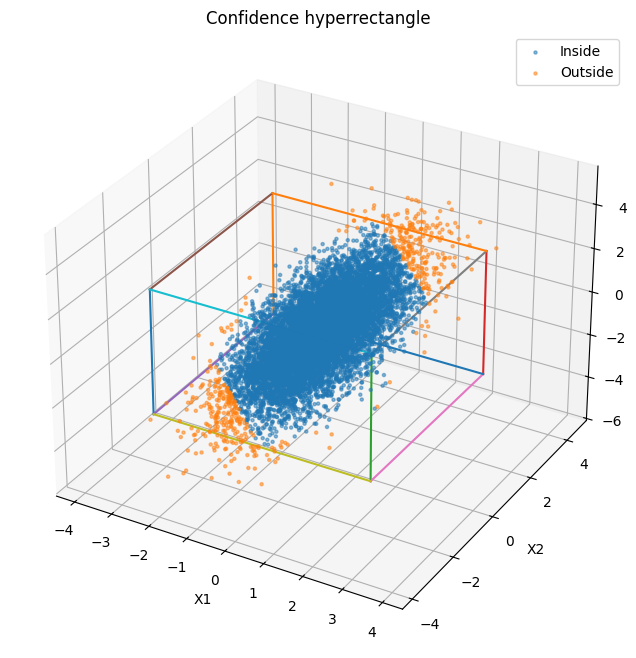

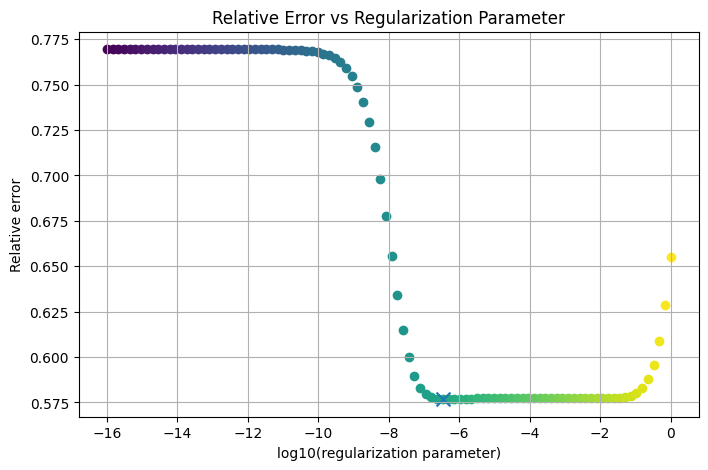

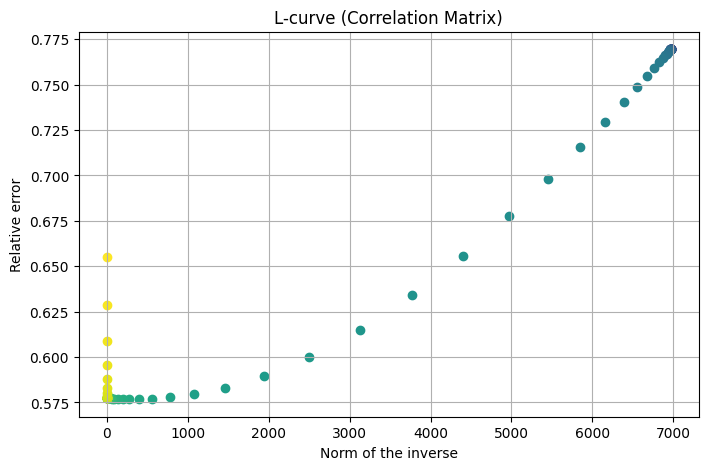


Execution time: 7.2749 seconds

Images saved successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as stats
import time
from mpl_toolkits.mplot3d import Axes3D


# =========================================================
# 1. GENERATE CORRELATED DATA
#
# X1, X2 independent normal variables
# X3 = X1 + X2 + epsilon
# =========================================================
def generate_correlated_data(
        n_samples=10000,
        noise=0.005,
        seed=42):

    np.random.seed(seed)

    X1 = np.random.randn(n_samples)

    X2 = np.random.randn(n_samples)

    epsilon = noise * np.random.randn(n_samples)

    # Linear dependence
    X3 = X1 + X2 + epsilon

    data = np.vstack((X1, X2, X3)).T

    return data


# =========================================================
# 2. TIKHONOV INVERSE
# =========================================================
def inverse_by_tikhonov(A, alpha):

    n = A.shape[0]

    I = np.eye(n)

    return np.linalg.inv(
        A.T @ A + alpha * I
    ) @ A.T


# =========================================================
# 3. COMPUTE REGULARIZATION ERRORS
# =========================================================
def compute_errors(
        C,
        n,
        regularization_values,
        num_trials=10):

    errors = []

    norms = []

    print("\nCorrelation matrix:")
    print(C)

    print("\nCondition number:")
    print(np.linalg.cond(C))

    K = np.ones((n, n))

    J = np.random.rand(n, n) - 0.5 * K

    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []

        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = C + r * J

            A_inv_tik = inverse_by_tikhonov(
                A,
                10**reg
            )

            error = (
                np.linalg.norm(
                    A_inv_tik @ C - I
                )
                /
                np.linalg.norm(I)
            )

            norm_inv = np.linalg.norm(
                A_inv_tik
            )

            trial_errors.append(error)

            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))

        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


# =========================================================
# 4. CONFIDENCE INTERVALS
#
# Based on:
#
# (x-mu)^T A (x-mu) <= 1
#
# with:
#
# A = R^{-1}/C
#
# The theorem gives:
#
# x_i = mu_i ± sqrt(alpha_ii)
#
# where alpha_ii are diagonal entries of A^{-1}
# =========================================================
def confidence_intervals_from_theorem(
        data,
        correlation_matrix,
        confidence_level=0.95):

    n, d = data.shape

    # Mean vector
    mu_hat = np.mean(data, axis=0)

    # Chi-square constant
    alpha = 1 - confidence_level

    C = stats.chi2.ppf(
        confidence_level,
        df=d
    )

    # -----------------------------------------------------
    # Ellipsoid:
    #
    # (x-mu)^T R^{-1} (x-mu) <= C
    #
    # Equivalent:
    #
    # (x-mu)^T A (x-mu) <= 1
    #
    # with:
    #
    # A = R^{-1}/C
    # -----------------------------------------------------

    A = np.linalg.inv(correlation_matrix) / C

    A_inv = np.linalg.inv(A)

    intervals = []

    for i in range(d):

        alpha_ii = A_inv[i, i]

        radius = np.sqrt(alpha_ii)

        intervals.append((
            mu_hat[i] - radius,
            mu_hat[i] + radius
        ))

    return mu_hat, intervals, C


# =========================================================
# 5. COUNT POINTS INSIDE HYPERRECTANGLE
# =========================================================
def count_points_inside(
        data,
        intervals):

    inside = []

    for x in data:

        inside_flag = True

        for i in range(len(intervals)):

            a, b = intervals[i]

            if not (a <= x[i] <= b):

                inside_flag = False
                break

        inside.append(inside_flag)

    inside = np.array(inside)

    n_inside = np.sum(inside)

    n_outside = len(data) - n_inside

    percentage = (
        100 * n_inside / len(data)
    )

    return inside, n_inside, n_outside, percentage


# =========================================================
# 6. PLOT HYPERRECTANGLE
# =========================================================
def plot_cube_and_points(
        data,
        intervals,
        inside_mask):

    fig = plt.figure(figsize=(8, 8))

    ax = fig.add_subplot(
        111,
        projection='3d'
    )

    Xin = data[inside_mask]

    Xout = data[~inside_mask]

    # Inside points
    ax.scatter(
        Xin[:, 0],
        Xin[:, 1],
        Xin[:, 2],
        s=5,
        alpha=0.5,
        label="Inside"
    )

    # Outside points
    ax.scatter(
        Xout[:, 0],
        Xout[:, 1],
        Xout[:, 2],
        s=5,
        alpha=0.5,
        label="Outside"
    )

    # Hyperrectangle limits
    xlim = intervals[0]
    ylim = intervals[1]
    zlim = intervals[2]

    xx = [xlim[0], xlim[1]]
    yy = [ylim[0], ylim[1]]
    zz = [zlim[0], zlim[1]]

    # Draw edges
    for x in xx:
        for y in yy:
            ax.plot([x, x], [y, y], zz)

    for x in xx:
        for z in zz:
            ax.plot([x, x], yy, [z, z])

    for y in yy:
        for z in zz:
            ax.plot(xx, [y, y], [z, z])

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("X3")

    ax.legend()

    plt.title(
        "Confidence hyperrectangle"
    )

    plt.savefig(
        "confidence_hyperrectangle.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    start_time = time.time()

    # -----------------------------------------------------
    # Generate data
    # -----------------------------------------------------
    data = generate_correlated_data(
        n_samples=10000,
        noise=0.005,
        seed=42
    )

    # -----------------------------------------------------
    # Correlation matrix
    # -----------------------------------------------------
    C = np.corrcoef(
        data,
        rowvar=False
    )

    # -----------------------------------------------------
    # Search best regularization parameter
    # -----------------------------------------------------
    n = 3

    regularization_values = np.linspace(
        -16,
        0,
        100
    )

    errors, norms = compute_errors(
        C,
        n,
        regularization_values
    )

    # -----------------------------------------------------
    # Optimal regularization
    # -----------------------------------------------------
    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_log_alpha = (
        regularization_values[min_index]
    )

    optimal_alpha = (
        10**optimal_log_alpha
    )

    print("\n--- Optimal Regularization ---")

    print(
        f"Minimum relative error: "
        f"{min_error:.6e}"
    )

    print(
        f"log10(alpha_opt) = "
        f"{optimal_log_alpha:.6f}"
    )

    print(
        f"alpha_opt = "
        f"{optimal_alpha:.6e}"
    )

    # -----------------------------------------------------
    # Regularized inverse
    # -----------------------------------------------------
    C_inv_reg = inverse_by_tikhonov(
        C,
        optimal_alpha
    )

    # Recover regularized correlation matrix
    C_reg = np.linalg.inv(
        C_inv_reg
    )

    # -----------------------------------------------------
    # Confidence intervals
    # -----------------------------------------------------
    mu_hat, intervals, chi2_constant = (
        confidence_intervals_from_theorem(
            data,
            C_reg,
            confidence_level=0.95
        )
    )

    print("\nChi-square constant:")
    print(chi2_constant)

    print("\nSample means:")
    print(mu_hat)

    print("\n95% confidence intervals:")

    for i, interval in enumerate(intervals):

        print(
            f"X_{i+1}: "
            f"({interval[0]:.4f}, "
            f"{interval[1]:.4f})"
        )

    # -----------------------------------------------------
    # Count points inside
    # -----------------------------------------------------
    inside_mask, n_in, n_out, percentage = (
        count_points_inside(
            data,
            intervals
        )
    )

    print("\nPoints inside hyperrectangle:")
    print(n_in)

    print("\nPoints outside hyperrectangle:")
    print(n_out)

    print("\nPercentage inside:")
    print(f"{percentage:.2f}%")

    # -----------------------------------------------------
    # Plot hyperrectangle
    # -----------------------------------------------------
    plot_cube_and_points(
        data,
        intervals,
        inside_mask
    )

    # -----------------------------------------------------
    # FIGURE 1
    # -----------------------------------------------------
    colors = cm.viridis(
        np.linspace(
            0,
            1,
            len(regularization_values)
        )
    )

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.scatter(
        optimal_log_alpha,
        min_error,
        marker='x',
        s=100
    )

    plt.xlabel(
        "log10(regularization parameter)"
    )

    plt.ylabel(
        "Relative error"
    )

    plt.title(
        "Relative Error vs Regularization Parameter"
    )

    plt.grid()

    plt.savefig(
        "correlation_relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # -----------------------------------------------------
    # FIGURE 2
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel(
        "Norm of the inverse"
    )

    plt.ylabel(
        "Relative error"
    )

    plt.title(
        "L-curve (Correlation Matrix)"
    )

    plt.grid()

    plt.savefig(
        "correlation_L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # -----------------------------------------------------
    # Execution time
    # -----------------------------------------------------
    execution_time = (
        time.time() - start_time
    )

    print(
        f"\nExecution time: "
        f"{execution_time:.4f} seconds"
    )

    print(
        "\nImages saved successfully."
    )

Save figures

In [ ]:
# =========================================================
# DOWNLOAD GENERATED IMAGES AS ZIP (GOOGLE COLAB)
# =========================================================

import zipfile
from google.colab import files

# ---------------------------------------------------------
# ZIP filename
# ---------------------------------------------------------
zip_filename = "generated_images.zip"

# ---------------------------------------------------------
# Generated image files
# ---------------------------------------------------------
image_files = [
    "confidence_hyperrectangle.png",
    "correlation_relative_error.png",
    "correlation_L_curve.png"
]

# ---------------------------------------------------------
# Create ZIP file
# ---------------------------------------------------------
with zipfile.ZipFile(zip_filename, "w") as zipf:

    for file in image_files:

        zipf.write(file)

print(f"{zip_filename} created successfully.")

# ---------------------------------------------------------
# Download ZIP
# ---------------------------------------------------------
files.download(zip_filename)

generated_images.zip created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>